# Advertising Workflow: An End-to-End Example

This notebook is a walkthrough of the reusable workflow modules developed throughout
this book, applied to the classic **Advertising** dataset (TV, radio, and newspaper
budgets predicting sales).

It follows exactly the same sequence as `run_workflow.py` and Chapter 13's
`run_modeling_pipeline.py`, but interactively — with extra tables and plots along the
way. Nothing here is *logic*; every step simply calls a function from `modules/`.

> If you copy this notebook into your own `notebooks/` folder, keep it at the top
> level of `notebooks/` so that `sys.path.append("..")` below resolves to the
> project root (the directory that contains `modules/`).


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from modules.data_io import load_dataset
from modules.eda import missing_summary, skewness_summary, correlation_summary
from modules.splitting import create_three_way_split, save_split
from modules.pipeline import PreprocessingPipeline, save_config, summarise_pipeline
from modules.modeling import (
    compute_vif, select_significant_features,
    ModelRegistry, evaluate_regression, save_model,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.precision", 4)


## 1. Load and Validate the Data

`load_dataset()` reads the CSV (caching it in memory) and immediately checks that the
columns this workflow depends on are present — failing fast with a clear message if
not.


In [2]:
URL = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = load_dataset(
    URL, index_col=0,
    required_columns=["TV", "radio", "newspaper", "sales"],
)

print(df.shape)
df.head()


(200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 2. Exploratory Data Analysis

`missing_summary()` and `skewness_summary()` give a quick standardized view of data
quality before any modelling decisions are made.


In [3]:
miss = missing_summary(df)
print("Missing values:")
print(miss.to_string(index=False) if not miss.empty else "  (none)")

print("\nSkewness:")
skewness_summary(df)[["column", "skewness", "high_skew"]]


Missing values:
  (none)

Skewness:


,column,skewness,high_skew
0,newspaper,0.8947,False
1,sales,0.4076,False
2,radio,0.0942,False
3,TV,-0.0699,False


`correlation_summary()` shows how strongly each feature relates to the target —
here we also visualise the full correlation matrix.


,correlation
TV,0.7822
radio,0.5762
newspaper,0.2283


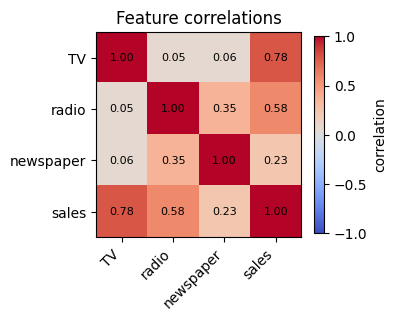

In [4]:
display(correlation_summary(df, target="sales"))

fig, ax = plt.subplots(figsize=(4, 3.5))
corr = df.corr(numeric_only=True)
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8, label="correlation")
ax.set_title("Feature correlations")
plt.tight_layout()
plt.show()


## 3. Create a Train / Validation / Test Split

`create_three_way_split()` gives us three *non-overlapping* sets: the training set
(used to fit the preprocessing pipeline and the models), the validation set (used to
choose between candidate models), and the test set (touched exactly once, at the very
end). `save_split()` persists the train/test portions to disk for reproducibility.


In [5]:
split = create_three_way_split(
    df, target="sales", test_size=0.2, val_size=0.1, random_state=42
)

print(f"train: {split.X_train.shape}, val: {split.X_val.shape}, test: {split.X_test.shape}")

save_split(split, "../data/splits/advertising")


train: (140, 3), val: (20, 3), test: (40, 3)
Split saved to '../data/splits/advertising' (140 train, 40 test rows)


## 4. Build and Fit the Preprocessing Pipeline

The configuration below mirrors Chapter 13: median/mean/constant imputation, IQR
capping on `TV` and `newspaper`, and standard scaling on all three predictors.

`fit_transform()` is called **only** on `X_train`; `X_val` and `X_test` are produced
with `transform()`, reusing the parameters learned from the training data.


In [6]:
config = {
    "missing":  {"strategies": {"TV": "median", "radio": "mean", "newspaper": 0.0},
                  "indicator_columns": []},
    "outliers": {"columns": ["TV", "newspaper"], "method": "iqr", "multiplier": 1.5},
    "scaling":  {"columns": ["TV", "radio", "newspaper"], "method": "standard"},
}

pipeline = PreprocessingPipeline(config)

X_train_clean = pipeline.fit_transform(split.X_train)
X_val_clean   = pipeline.transform(split.X_val)
X_test_clean  = pipeline.transform(split.X_test)

summarise_pipeline(pipeline)
X_train_clean.head()


PREPROCESSING PIPELINE SUMMARY

[1] Missing Data Imputation
    TV: strategy='median', fill_value=157.5000
    radio: strategy='mean', fill_value=23.9414
    newspaper: strategy='0.0', fill_value=0.0000

[2] Outlier Capping (method=iqr, multiplier=1.5)
    TV: [-137.09, 435.81]
    newspaper: [-32.00, 92.40]

[3] Feature Scaling (method=standard)
    TV: mean=150.5143, std=85.1696
    radio: mean=23.9414, std=14.4311
    newspaper: mean=31.0221, std=20.3925


,TV,radio,newspaper
124,-0.3219,0.7386,-0.9132
173,-1.5371,-0.2662,-0.6876
6,-1.6651,1.7295,2.1566
87,-0.8714,0.2466,-0.7367
128,-0.8256,-1.6590,-1.0701


## 5. Diagnostics: Multicollinearity and Feature Significance

`compute_vif()` checks for multicollinearity among the predictors (values well below
5 indicate no problem here). `select_significant_features()` fits an OLS model and
keeps only the features with statistically significant coefficients.


In [7]:
display(compute_vif(X_train_clean[["TV", "radio", "newspaper"]]))

X_sig, sig_summary = select_significant_features(X_train_clean, split.y_train, alpha=0.05)
print("Significant features:", list(X_sig.columns))
sig_summary


,feature,VIF
0,radio,1.1537
1,newspaper,1.1482
2,TV,1.0062


Significant features: ['TV', 'radio']


,feature,coef,p_value,significant
0,const,14.3179,0.0000,True
1,TV,3.9803,0.0000,True
2,radio,2.6758,0.0000,True
3,newspaper,0.0298,0.8403,False


## 6. Train and Compare Candidate Models

`ModelRegistry` trains every registered model on `X_train` / `y_train`, evaluates each
on the *validation* set, and ranks them — here, by RMSE.


In [8]:
registry = (
    ModelRegistry(task="regression")
    .register("linear_regression", LinearRegression())
    .register("ridge", Ridge(alpha=1.0))
    .register("random_forest", RandomForestRegressor(n_estimators=100, random_state=42))
    .register("gradient_boosting", GradientBoostingRegressor(n_estimators=100, random_state=42))
)

results = registry.fit_all(X_train_clean, split.y_train, X_val_clean, split.y_val)
results[["model", "r2", "rmse"]]


Trained: linear_regression (LinearRegression)
Trained: ridge (Ridge)
Trained: random_forest (RandomForestRegressor)


Trained: gradient_boosting (GradientBoostingRegressor)


,model,r2,rmse
0,gradient_boosting,0.9713,0.6915
1,random_forest,0.9672,0.7395
2,ridge,0.7432,2.0681
3,linear_regression,0.7399,2.0816


## 7. Final Evaluation on the Test Set

The test set has not been used anywhere above — not for fitting the pipeline, and not
for choosing the model. It is used exactly once, here.


In [9]:
best_name, best_model = registry.get_best()
print(f"Best model (by validation RMSE): {best_name}")

final_metrics = evaluate_regression(best_model, X_test_clean, split.y_test, label="test")
final_metrics


Best model (by validation RMSE): gradient_boosting


{'label': 'test',
 'r2': 0.9842,
 'rmse': np.float64(0.7069),
 'mae': 0.592,
 'mape': 0.0539}

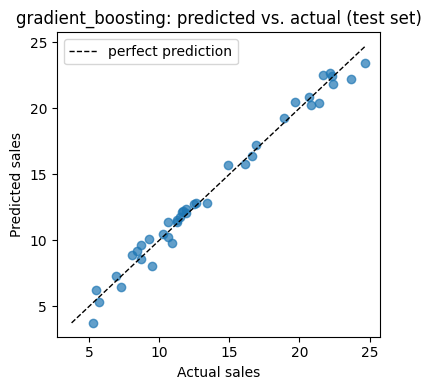

In [10]:
preds = best_model.predict(X_test_clean)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(split.y_test, preds, alpha=0.7)
lims = [min(split.y_test.min(), preds.min()), max(split.y_test.max(), preds.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
ax.set_xlabel("Actual sales")
ax.set_ylabel("Predicted sales")
ax.set_title(f"{best_name}: predicted vs. actual (test set)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Save Artifacts for Reuse

Saving the config, the fitted pipeline, and the winning model means a separate
inference script can reload all three and reproduce this exact pipeline on new data —
without needing to refit anything.


In [11]:
save_config(config, "../models/pipeline_config.json")
pipeline.save("../models/preprocessing_pipeline.pkl")
save_model(best_model, "../models/best_model.joblib")


Config saved to '../models/pipeline_config.json'
Pipeline saved to '../models/preprocessing_pipeline.pkl'
Model saved to '../models/best_model.joblib'


## Summary

This notebook exercised every module in `modules/` against a real dataset:

- `data_io.load_dataset()` — loading with validation
- `eda.missing_summary()`, `skewness_summary()`, `correlation_summary()` — quick diagnostics
- `splitting.create_three_way_split()`, `save_split()` — reproducible, leakage-free splits
- `pipeline.PreprocessingPipeline` — fit/transform preprocessing
- `modeling.compute_vif()`, `select_significant_features()` — feature diagnostics
- `modeling.ModelRegistry` — training and comparing candidate models
- `modeling.evaluate_regression()` — final, single-use test evaluation
- `pipeline.save_config()`, `PreprocessingPipeline.save()`, `modeling.save_model()` — artifact persistence

For the script version of the same workflow, see `run_workflow.py`. For an automated
check that this pipeline still runs end-to-end, see `tests/test_pipeline_runs.py`.
